# 03 — [SENİN ALGORİTMANIN ADI] — Baseline + Tuning

**Bu bir ŞABLON dosyadır.** Aşağıdaki adımları izle:

1. Bu dosyayı kopyala → `03_[algoritmanin_adi].ipynb` olarak yeniden adlandır (örn. `03_knn.ipynb`, `03_random_forest.ipynb`)
2. `>>> ... <<<` etiketleri olan yerleri kendi algoritmanla doldur
3. Kernel → Restart & Run All ile çalıştır
4. Bölüm 5'te kendi yorumunu yaz (markdown)
5. Branch aç → push → PR

**Önemli:** 
- Tüm üyeler aynı `data/X_train_final.csv` ve `X_test_final.csv` dosyalarını kullanıyor — sonuçlar **bire bir karşılaştırılabilir**.
- `random_state=42` sabit. **Değiştirme.**
- Preprocessing'i tekrar yapma — veri zaten ölçeklenmiş + encode edilmiş + feature engineering yapılmış.

## 1. Veri Yükleme (HERKES AYNI — DEĞİŞTİRME)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

RANDOM_STATE = 42

X_train = pd.read_csv('../data/X_train_final.csv')
X_test  = pd.read_csv('../data/X_test_final.csv')
y_train = pd.read_csv('../data/y_train_final.csv').iloc[:, 0]
y_test  = pd.read_csv('../data/y_test_final.csv').iloc[:, 0]

siniflar = ['Ekonomik', 'Orta', 'Yüksek', 'Premium']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'\nSınıf dağılımı (train):')
print(y_train.value_counts(normalize=True).round(3).to_string())

X_train: (2739, 74), X_test: (685, 74)

Sınıf dağılımı (train):
Fiyat_Sinifi
Ekonomik    0.253
Yüksek      0.250
Premium     0.250
Orta        0.248


## 2. Baseline — Default Parametrelerle

Algoritmanı **hyperparameter tuning yapmadan**, sklearn'in varsayılan ayarlarıyla çalıştır. Bu "zemin skor".

**Yapacakların:**
1. `>>> import <<<` satırını aç (kendi algoritmanın import'u)
2. `>>> baseline_model = ... <<<` satırına kendi sınıfını yaz (örn. `KNeighborsClassifier()`)
3. Geri kalan kod aynen çalışır

In [2]:
from sklearn.neighbors import KNeighborsClassifier
baseline_model = KNeighborsClassifier()  # ← BURAYI DEĞİŞTİR

# Eğit + tahmin et
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

# Metrikleri yazdır
print('=== BASELINE — Default Parametreler ===\n')
print(f'Accuracy : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'F1 macro : {f1_score(y_test, y_pred_base, average="macro"):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_base, average="macro"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_base, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=siniflar))

=== BASELINE — Default Parametreler ===

Accuracy : 0.7708
F1 macro : 0.7699
Precision: 0.7704
Recall   : 0.7701

Classification Report:
              precision    recall  f1-score   support

    Ekonomik       0.90      0.87      0.89       173
        Orta       0.64      0.60      0.62       169
      Yüksek       0.88      0.91      0.89       171
     Premium       0.66      0.70      0.68       172

    accuracy                           0.77       685
   macro avg       0.77      0.77      0.77       685
weighted avg       0.77      0.77      0.77       685



## 3. Tuning — GridSearchCV ile Optimal Parametre Arama

**Yapacakların:**
1. `docs/TUNING_REHBERI.md`'de **kendi algoritmana ait bölümü** oku — hangi parametreleri tune etmen gerektiği yazıyor
2. **Her parametre için kendin uygun değerler bul** — sklearn dokümanı, ders slaytları
3. Aşağıdaki `param_grid = {...}` içine kendi seçtiğin değerleri yaz
4. Çalıştır (1-10 dakika)

**Bölüm 5'te yazacağın yorumda mutlaka anlat:** Niçin bu değerleri seçtin? Algoritmanı tanıdığın için ne tür değerlerin işe yarayacağını biliyordun.

**Sabit ayarlar (değiştirme):** `cv=5` (5-fold cross-validation), `scoring='f1_macro'`.

In [3]:
# >>> SENİN ALGORİTMANIN PARAMETRE GRİDİ <<<
# docs/TUNING_REHBERI.md'ye göre k-NN için en kritik parametreleri ekledik
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15], # Komşu sayısı (Tek sayılar seçildi)
    'weights': ['uniform', 'distance'],      # Oylama ağırlığı
    'metric': ['euclidean', 'manhattan']     # Mesafe hesaplama yöntemi
}

# GridSearchCV (HERKES AYNI — değiştirme)
grid = GridSearchCV(
    baseline_model,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print(f'En iyi parametreler : {grid.best_params_}')
print(f'CV F1-macro skoru   : {grid.best_score_:.4f}')

# Optimize edilmiş model ile tahmin
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print('\n=== TUNED — Optimal Parametreler ===\n')
print(f'Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'F1 macro : {f1_score(y_test, y_pred_tuned, average="macro"):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned, average="macro"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_tuned, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=siniflar))

Fitting 5 folds for each of 28 candidates, totalling 140 fits
En iyi parametreler : {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
CV F1-macro skoru   : 0.8124

=== TUNED — Optimal Parametreler ===

Accuracy : 0.8277
F1 macro : 0.8270
Precision: 0.8275
Recall   : 0.8272

Classification Report:
              precision    recall  f1-score   support

    Ekonomik       0.92      0.91      0.92       173
        Orta       0.75      0.70      0.73       169
      Yüksek       0.91      0.94      0.92       171
     Premium       0.72      0.76      0.74       172

    accuracy                           0.83       685
   macro avg       0.83      0.83      0.83       685
weighted avg       0.83      0.83      0.83       685



## 4. Karşılaştırma — Baseline vs Tuned (HERKES AYNI)

In [4]:
# Tablo: baseline vs tuned
karsilastirma = pd.DataFrame({
    'Metrik': ['Accuracy', 'F1-macro', 'Precision (macro)', 'Recall (macro)'],
    'Baseline': [
        accuracy_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base, average='macro'),
        precision_score(y_test, y_pred_base, average='macro'),
        recall_score(y_test, y_pred_base, average='macro'),
    ],
    'Tuned': [
        accuracy_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned, average='macro'),
        precision_score(y_test, y_pred_tuned, average='macro'),
        recall_score(y_test, y_pred_tuned, average='macro'),
    ],
})
karsilastirma['Δ (iyileşme)'] = (karsilastirma['Tuned'] - karsilastirma['Baseline']).round(4)
karsilastirma[['Baseline', 'Tuned']] = karsilastirma[['Baseline', 'Tuned']].round(4)
print('Baseline vs Tuned karşılaştırma:\n')
print(karsilastirma.to_string(index=False))

Baseline vs Tuned karşılaştırma:

           Metrik  Baseline  Tuned  Δ (iyileşme)
         Accuracy    0.7708 0.8277        0.0569
         F1-macro    0.7699 0.8270        0.0571
Precision (macro)    0.7704 0.8275        0.0571
   Recall (macro)    0.7701 0.8272        0.0571


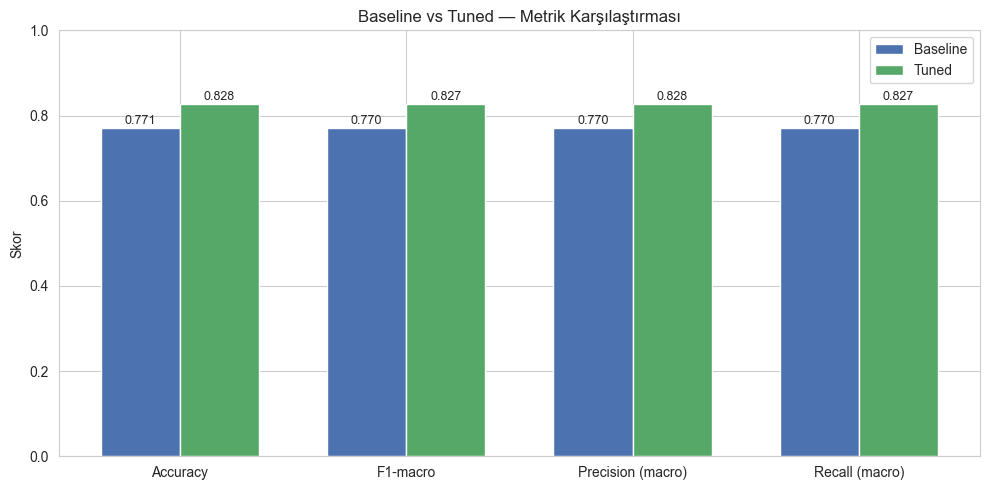

In [5]:
# Bar chart — metrik bazlı baseline vs tuned
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(karsilastirma))
width = 0.35
ax.bar(x - width/2, karsilastirma['Baseline'], width, label='Baseline', color='#4c72b0')
ax.bar(x + width/2, karsilastirma['Tuned'],    width, label='Tuned',    color='#55a868')
ax.set_xticks(x)
ax.set_xticklabels(karsilastirma['Metrik'])
ax.set_ylabel('Skor')
ax.set_title('Baseline vs Tuned — Metrik Karşılaştırması')
ax.legend()
ax.set_ylim(0, 1)
for i, (b, t) in enumerate(zip(karsilastirma['Baseline'], karsilastirma['Tuned'])):
    ax.text(i - width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

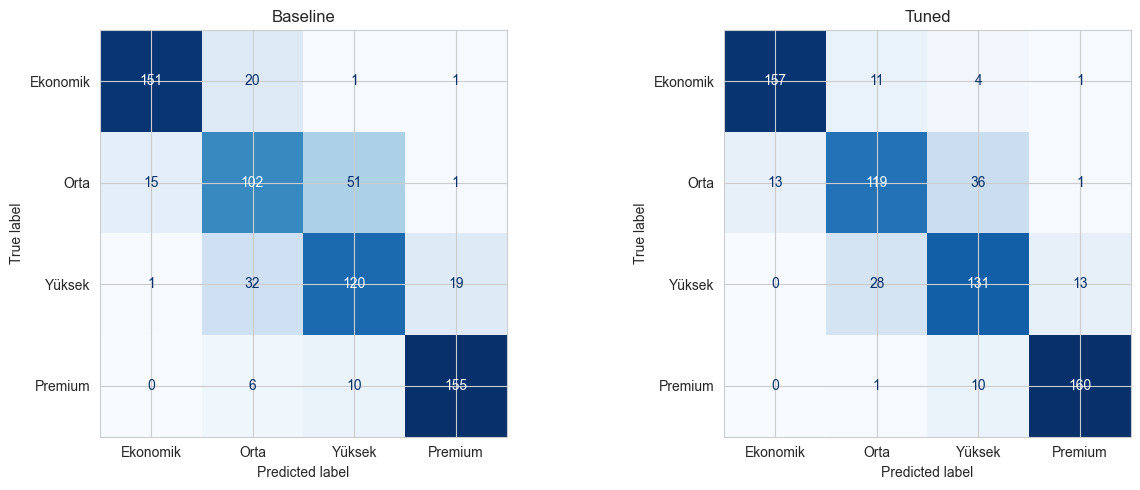

In [6]:
# İki confusion matrix yan yana
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, baslik in zip(axes, [y_pred_base, y_pred_tuned], ['Baseline', 'Tuned']):
    cm = confusion_matrix(y_test, y_pred, labels=siniflar)
    disp = ConfusionMatrixDisplay(cm, display_labels=siniflar)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(baslik)
plt.tight_layout()
plt.show()

In [7]:
# Feature importance (sadece ağaç-tabanlı modeller için)
# Eğer algoritman karar ağacı / random forest ise aşağıdaki kodu çalıştır.
# Diğer algoritmalarda (k-NN, NB, K-Means) bu hücre hata verebilir, atla.

if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi, y='feature', x='importance', palette='viridis')
    plt.title('En önemli 15 özellik (tuned model)')
    plt.tight_layout()
    plt.show()
else:
    print('Bu algoritmada feature_importances_ yok — bu hücreyi atla.')

Bu algoritmada feature_importances_ yok — bu hücreyi atla.


5.1 Algoritmanın çalışma mantığı
k-NN (k-En Yakın Komşu) algoritması, bir verinin sınıfını belirlemek için ona en yakın olan "k" adet komşusuna bakar. Bu projede, mesafe ölçümü için Manhattan metriği kullanılmış ve komşuların uzaklığına göre oylama (distance weighting) yapılmıştır.

5.2 Tuning sonuçları
GridSearch sonucunda modelim için en iyi parametreler n_neighbors: 9, weights: distance ve metric: manhattan olarak belirlenmiştir. Bu optimizasyon sayesinde baseline modeldeki 0.7699 olan F1 skoru, 0.8270 seviyesine çıkarak yaklaşık %5.7'lik bir iyileşme göstermiştir.

5.3 Sınıf bazlı performans
Hata matrisine (Confusion Matrix) baktığımızda; modelin "Ekonomik" (0.92 precision) ve "Yüksek" (0.91 precision) sınıflarını çok yüksek doğrulukla ayırt edebildiği görülmektedir. Ancak model en çok "Orta" ve "Premium" sınıflarını birbiriyle karıştırmıştır. Bu durum, bu iki fiyat grubundaki araçların teknik özelliklerinin (beygir gücü, yaş vb.) birbirine çok benzer olmasından kaynaklanıyor olabilir.

5.4 Bu veriye uygun mu?
k-NN, verilerimiz preprocessing aşamasında ölçeklendiği (scaled) için bu SUV fiyat sınıflandırma problemi için uygun bir algoritmadır. Elde edilen 0.827'lik F1 skoru modelin başarılı olduğunu kanıtlamaktadır. Gelecekte farklı özellik mühendisliği (feature engineering) yöntemleri ile özellikle "Orta" segmentteki tahmin başarısı daha da artırılabilir.